# A5 CW Solutions: Fitting QNMs
### Joey Wee

- Let's start by examining and plotting the data.dat file.

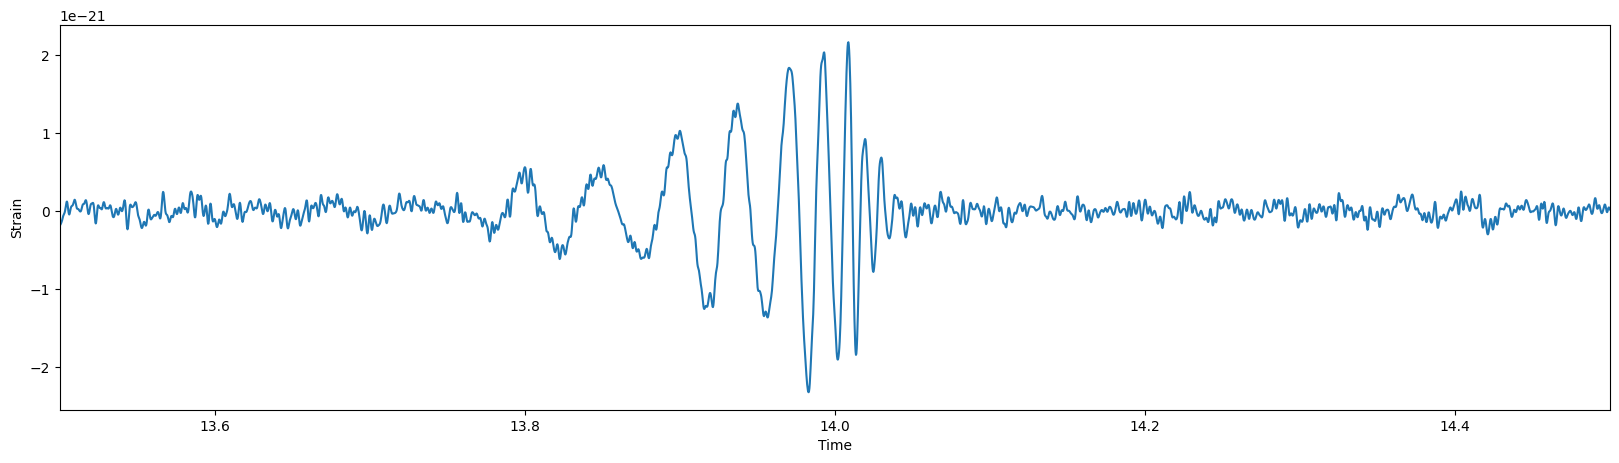

In [353]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('data.dat', skiprows=1)

fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Time")
ax.set_ylabel("Strain")
ax.plot(data[:,0], data[:,1])
ax.set_xlim(13.5,14.5)

t = data[:,0]
strain = data[:,1]


In [354]:
import qnm
qnm.download_data()

Destination path C:\Users\Joey\.qnm\data-0.4.0.tar.bz2 already exists, use overwrite=True to force an overwrite.


- Any black hole can be described by the mass $M$ and the angular momentum $J = \chi M^2$. $\chi \in [0,1[$ 

## Q1: Calculate the dimensionless frequencies
- Consider (l, m, n) = (2, 2, 0) and (3, 3, 0)
- Calculate the dimensionless frequencies.
- Plot the real and imaginary parts of those frequencies.
    - The real part is the oscillatin' part.
    - The imaginary part causes the pertrubation to decay in time.


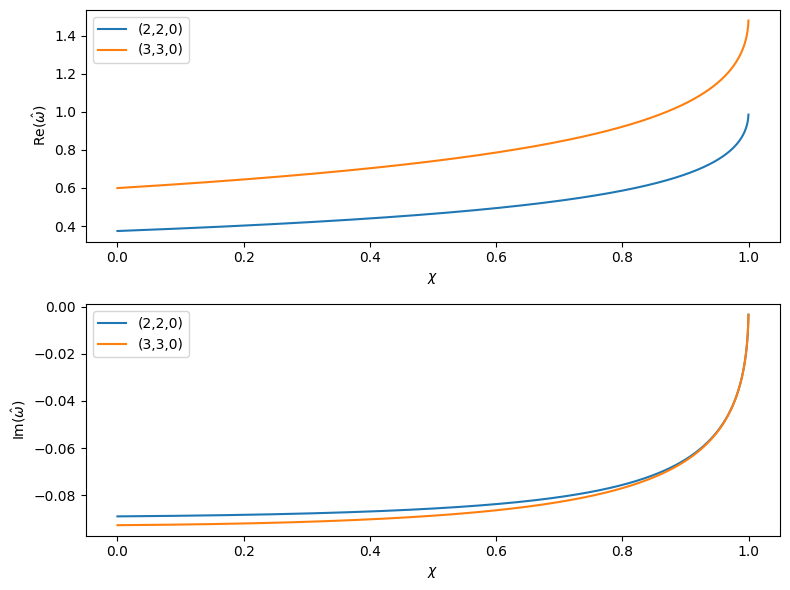

In [ ]:
chi_values = np.linspace(0, 0.9999, 100000)

# Storage
omega_220 = []
omega_330 = []

# Get mode objects
mode_220 = qnm.modes_cache(s=-2, l=2, m=2, n=0)
mode_330 = qnm.modes_cache(s=-2, l=3, m=3, n=0)

# Loop over chi values
for chi in chi_values:
    w220, _, _ = mode_220(chi)
    w330, _, _ = mode_330(chi)
    omega_220.append(w220)
    omega_330.append(w330)

# Convert to numpy arrays
omega_220 = np.array(omega_220)
omega_330 = np.array(omega_330)

# Now plot real and imaginary parts separately
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.plot(chi_values, omega_220.real, label='(2,2,0)')
ax1.plot(chi_values, omega_330.real, label='(3,3,0)')
ax1.set_ylabel(r'$\mathrm{Re}(\hat{\omega})$')

ax2.plot(chi_values, omega_220.imag, label='(2,2,0)')
ax2.plot(chi_values, omega_330.imag, label='(3,3,0)')
ax2.set_ylabel(r'$\mathrm{Im}(\hat{\omega})$')

for ax in (ax1, ax2):
    ax.set_xlabel(r'$\chi$')
    ax.legend()

plt.tight_layout()
plt.show()

## Q2: Splitting Data
- Data has off and on-source regimes. How should I split them?
- There is also a time $t_0$ where the ringdown begins. How to identify?
- *Only analyse on-source at $t>t_0$*.

----
- Ideas:
    - Find peaks to find the maxima and minima. The highest can be the start of ringodown. 
    - Moving window. When is variance larger? This can find on-source.
    - Spectrogram to find on source? Can identify region where the signals are clearly different.

#### Spectrogram

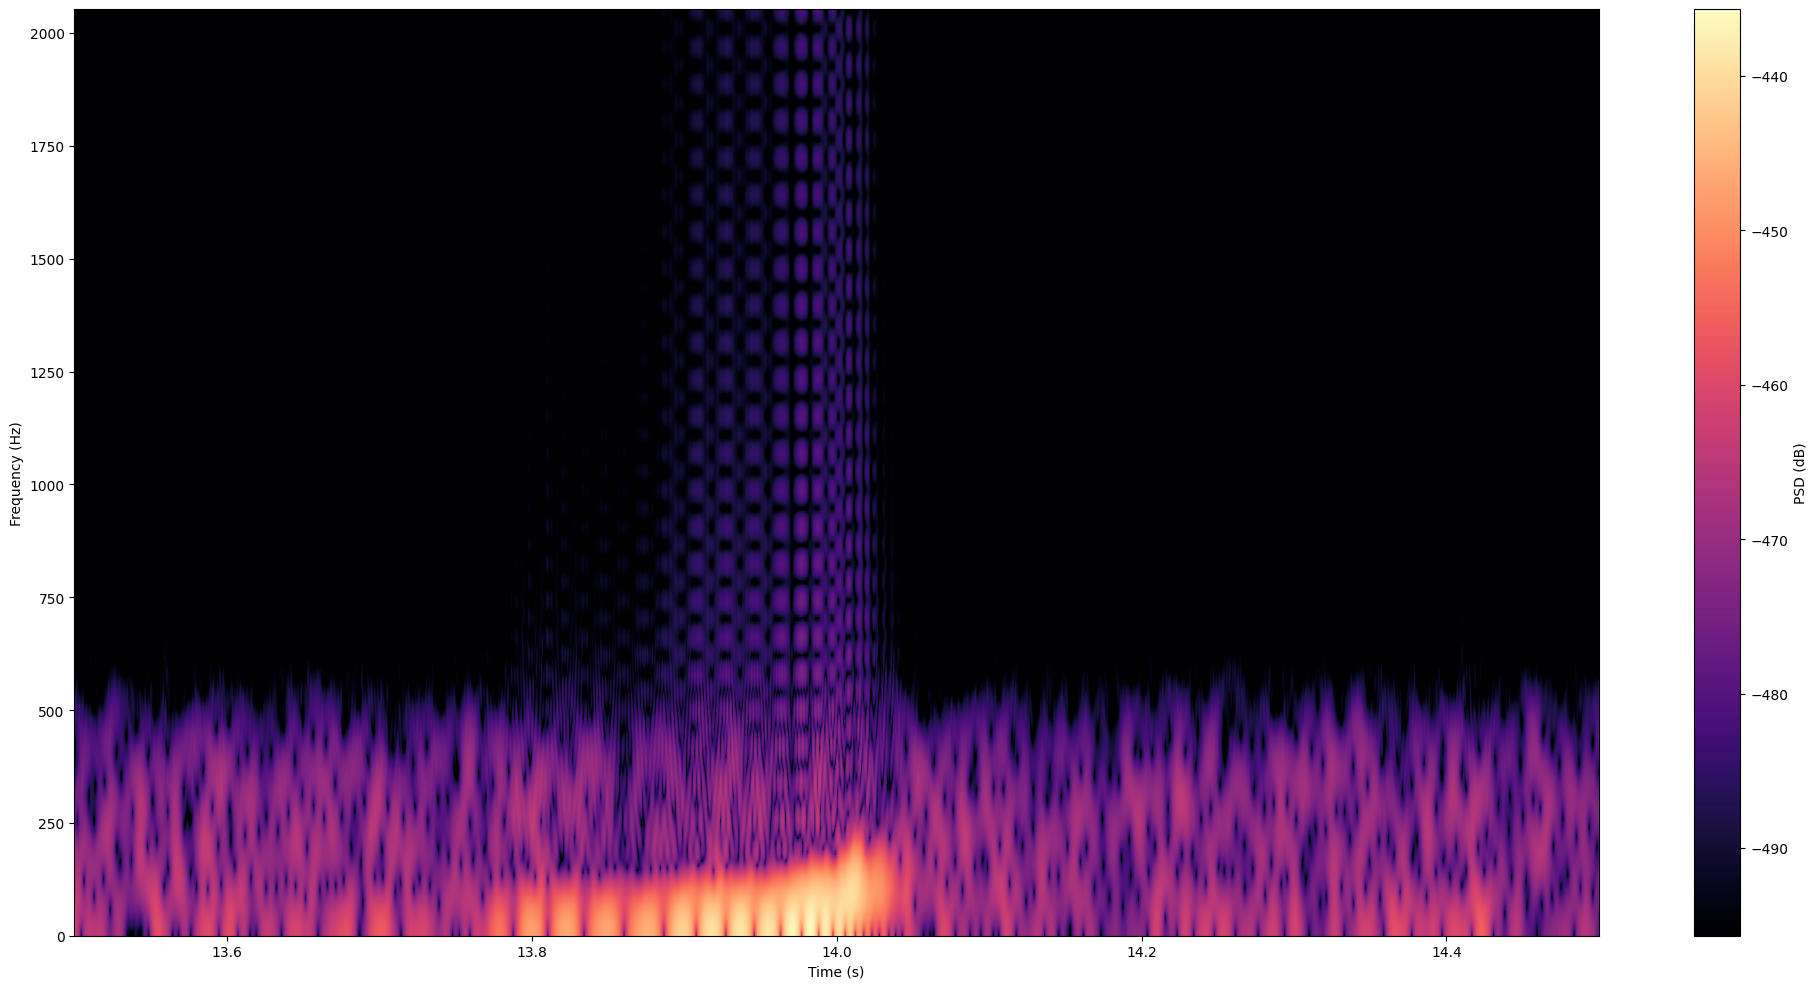

In [356]:
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import gaussian


# 32 seconds of data at 4096 Hz
# Let's spectrogram at 100 Hz
 
T_x = 1/4096 # Time between samples
N = len(t) # Number of samples

# Time indices for the signal
t_x = np.arange(N) * T_x # N time ppoints spanning across N*T_x seconds

# Create windows using Gaussian weighting to prevent frequency artefacts
g_std = 12 # Width of Gaussian window
win  = gaussian(50, std=g_std, sym=True)
SFT = ShortTimeFFT(win, hop=2, fs=1/T_x, mfft=800, scale_to='psd')
Sx2 = SFT.spectrogram(strain) # Magnitude squared "x2"

Sx_dB = 10 * np.log10(np.fmax(Sx2, Sx2.max() * 1e-6))

fig, ax = plt.subplots(figsize= (20,10))
t_lo, t_hi = SFT.extent(N)[:2] # Slightly wider time range because of the windows
ax.set_xlim(13.5,14.5)
im = ax.imshow(Sx_dB, origin='lower', aspect='auto',
               extent=SFT.extent(N), cmap='magma')
ax.set(xlabel='Time (s)', ylabel='Frequency (Hz)')
fig.colorbar(im, label='PSD (dB)')
fig.tight_layout()
plt.show()





- We can see here that, compared to the background, 13.7 to 14.1 is different. We can treat this as out on-signal time. 
- This agrees with the strain vs time plot well.
- We can use a Hilbert transform the signal to get the amplitude term.
- We take the peak of this amplitude to be the start of our ringdown time $t_0$.

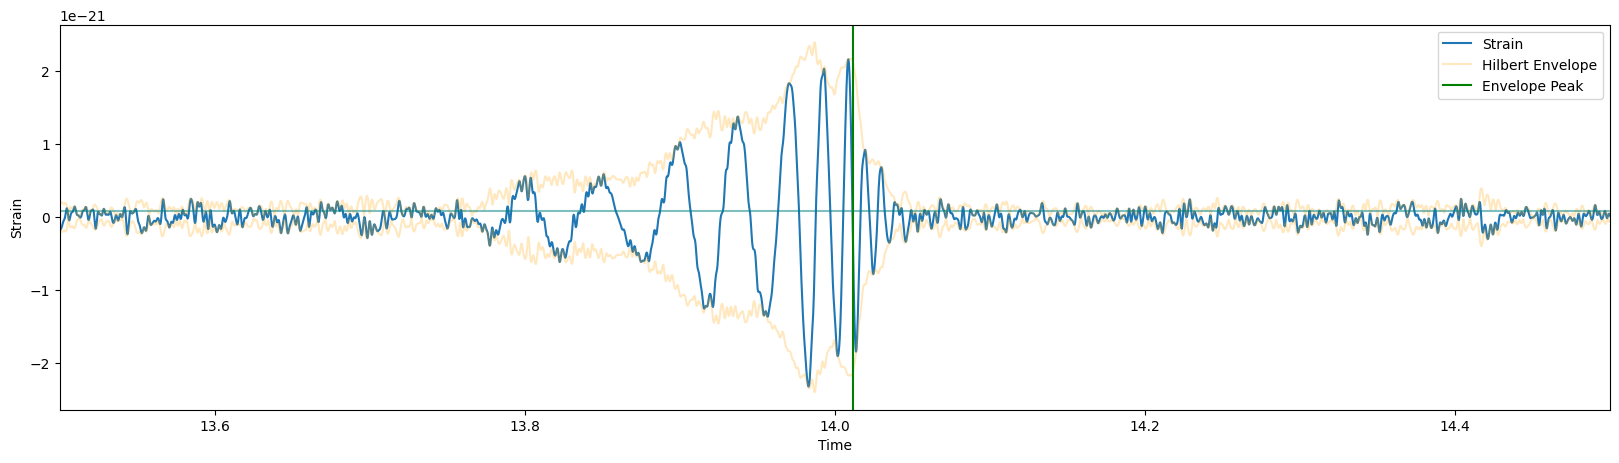

In [357]:
from scipy.signal import hilbert

analytic = hilbert(strain)
envelope = np.abs(analytic)
t0 = t[np.argmax(envelope)]

fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Time")
ax.set_ylabel("Strain")
ax.plot(t, strain, label='Strain')
ax.plot(t, envelope, alpha=0.25, label='Hilbert Envelope', color='orange')
ax.plot(t, -envelope, alpha=0.25, color='orange')
ax.axvline(t0+0.025, color='green', label='Envelope Peak')
ax.axhline(8.32e-23, color='teal', alpha=0.5)
ax.set_xlim(13.5,14.5)
ax.legend()

In [358]:
on_times = (13.7, 14.1)
t0 = t0+0.025

## Q3: Estimate the $\sigma$
- I think it would be reasonable to use the standard deviation of the off-source data.

In [376]:
on_time_start, on_time_end = on_times
off_strain = strain[(t < on_time_start) | (t > on_time_end)]
off_std = np.std(off_strain)


#------
t_on = t[(t > on_time_start) & (t < on_time_end)]
d_on = strain[(t > on_time_start) & (t < on_time_end)]

t_off_1 = t[(t < on_time_start)]
d_off_1 = strain[(t < on_time_start)]

t_off_2 = t[(t > on_time_end)]
d_off_2 = strain[(t > on_time_end)]

t_ring = t_on[t_on > t0]
d_ring = d_on[t_on > t0]

## Q4: Sample parameters
- Priors:
    - A we dk amplitude so use 5x max ringdown strain as upper bound and 0 as a lower bound with log-uniform.
    - Phi is uniform between 0 and 2 pi.
    - f is log-uniform between 0 and the data frequency.
    - Tau is log-uniform between 0 and the data length.

In [360]:
# import emcee

# def ringdown_model(t, A1, phi1, f1, tau1, A2, phi2, f2, tau2, t0): # this is h(t)
#     h1 = A1 * np.cos(2*np.pi*f1*(t - t0) + phi1) * np.exp(-(t - t0)/tau1)
#     h2 = A2 * np.cos(2*np.pi*f2*(t - t0) + phi2) * np.exp(-(t - t0)/tau2)
#     return h1 + h2

# def lnPi(theta):
#     A1, phi1, f1, tau1, A2, phi2, f2, tau2 = theta

#     A_min, A_max = 0, 1e-20
#     phi_min, phi_max = -np.pi, np.pi
#     f_min, f_max = 0, 4096
#     tau_min, tau_max = 0, 32
    
#     # log-uniform on amplitudes
#     if not (A_min < A1 < A_max and A_min < A2 < A_max):
#         return -np.inf
    
#     # uniform on phases
#     if not (phi_min < phi1 < phi_max and phi_min < phi2 < phi_max):
#         return -np.inf
    
#     # log-uniform on frequencies (Hz) - adjust range to your signal
#     if not (f_min < f1 < f_max and f_min < f2 < f_max):
#         return -np.inf
    
#     # log-uniform on damping times (s)
#     if not (tau_min < tau1 < tau_max and tau_min < tau2 < tau_max):
#         return -np.inf
    
#     # log-uniform prior contribution for amplitudes
#     lp = -np.log(A1) - np.log(A2)
#     lp += -np.log(f1) - np.log(f2)
#     lp += -np.log(tau1) - np.log(tau2)
#     return lp

# def lnL(theta, t, data, std=off_std):
#     A1, phi1, f1, tau1, A2, phi2, f2, tau2 = theta
#     h = ringdown_model(t, A1, phi1, f1, tau1, A2, phi2, f2, tau2, t0)
#     return -0.5 * np.sum((data - h)**2 / std**2)

# def lnPost(theta, t, d, sigma):
#     lp = lnPi(theta)
#     if not np.isfinite(lp):
#         return -np.inf
#     return lp + lnL(theta, t, d, sigma)

# # Run Emcee
# ndim = 8
# nwalkers = 64  # must be > 2*ndim, even number

# # Define the center of your initial ball
# # (A1,    phi1, f1,    tau1,  A2,    phi2, f2,    tau2)
# p0_guess = np.array([1e-22, 0.0, 150.0, 0.01, 1e-22, 0.0, 250.0, 0.01])

# # Define spread for each parameter individually
# p0_spread = np.array([1e-23, 0.1, 10.0, 0.001, 1e-23, 0.1, 10.0, 0.001])

# rng = np.random.default_rng(1701)
# p0 = p0_guess + p0_spread * rng.standard_normal((nwalkers, ndim))

# sampler = emcee.EnsembleSampler(
#     nwalkers, ndim, lnPost,
#     args=(t_on, d_on, off_std)  # your on-source data after t0
# )

In [361]:
# state = sampler.run_mcmc(p0, 50000, progress=True)

In [362]:
# param_names = ['A1', 'phi1', 'f1', 'tau1', 'A2', 'phi2', 'f2', 'tau2']
# fig, axes = plt.subplots(ndim, figsize=(10, 3.5 * ndim), sharex=True)

# chain = sampler.get_chain() # chain shape is (nwalkers, nsteps, ndim)

# for i, ax in enumerate(axes):
#     ax.plot(chain[:, :, i], alpha=0.3, lw=0.5)   # all walkers
#     ax.set_ylabel(param_names[i])

# axes[-1].set_xlabel("Step")
# axes[0].legend()
# plt.tight_layout()
# plt.show()

- Let's discard the first 20k steps.

In [363]:
# burn_in = 20000
# thin = 100

# flat_samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)
# print("Flat samples shape:", flat_samples.shape)  # (n_samples, ndim)

In [364]:
# import corner

# labels = [r"$A_1$", r"$\phi_1$", r"$f_1$", r"$\tau_1$",
#           r"$A_2$", r"$\phi_2$", r"$f_2$", r"$\tau_2$"]

# fig = corner.corner(
#     flat_samples,
#     labels=labels,
#     quantiles=[0.16, 0.5, 0.84],  # 1-sigma credible intervals
#     show_titles=True,
#     title_fmt=".2e",
# )

- This is nasty let's use dynesty instead.

In [379]:
def lnL(theta):
    A1, phi1, f1, tau1, A2, phi2, f2, tau2 = theta
    t = t_ring
    model = (A1 * np.cos(2*np.pi*f1*(t - t0) + phi1) * np.exp(-(t - t0)/tau1) +
             A2 * np.cos(2*np.pi*f2*(t - t0) + phi2) * np.exp(-(t - t0)/tau2))
    residuals = d_ring - model  # d is your on-source data, t > t0
    return -0.5 * np.sum(residuals**2 / off_std**2)

def prior_transform(u):
    A1_u, phi1_u, f1_u, tau1_u, A2_u, phi2_u, f2_u, tau2_u = u

    # log-uniform on amplitudes 
    A_min, A_max = 1e-25, 1e-19
    A1   = A_min * (A_max / A_min) ** A1_u
    A2   = A_min * (A_max / A_min) ** A2_u

    # uniform on phases [-pi, pi]
    phi1 = -np.pi + phi1_u * 2 * np.pi
    phi2 = -np.pi + phi2_u * 2 * np.pi

    # log-uniform on frequencies 
    f_min, f_max = 20.0, 4096.0
    f1   = f_min * (f_max / f_min) ** f1_u
    f2   = f_min * (f_max / f_min) ** f2_u

    # log-uniform on damping times 
    tau_min, tau_max = 1e-4, 1e-1
    tau1 = tau_min * (tau_max / tau_min) ** tau1_u
    tau2 = tau_min * (tau_max / tau_min) ** tau2_u

    return [A1, phi1, f1, tau1, A2, phi2, f2, tau2]

In [380]:
import dynesty

sampler = dynesty.DynamicNestedSampler(
    lnL,
    prior_transform,
    ndim=8,
    bound='multi',    # multiellipsoid bounding (good default)
    sample='rwalk'    # random walk sampling
)

sampler.run_nested(print_progress=True)

29625it [01:33, 315.34it/s, batch: 4 | bound: 5 | nc: 1 | ncall: 770774 | eff(%):  3.777 | loglstar: -185.947 < -178.601 < -180.491 | logz: -219.541 +/-  0.215 | stop:  0.916]            


In [381]:
from dynesty import utils as dyfunc

results = sampler.results

# Resample to equal weights (important — dynesty samples are not equal weight)
weights = np.exp(results.logwt - results.logz[-1])
samples = dyfunc.resample_equal(results.samples, weights)

# samples has shape (N, 8)
# columns match your parameter order: A1, phi1, f1, tau1, A2, phi2, f2, tau2
A1, phi1, f1, tau1 = samples[:,0], samples[:,1], samples[:,2], samples[:,3]
A2, phi2, f2, tau2 = samples[:,4], samples[:,5], samples[:,6], samples[:,7]

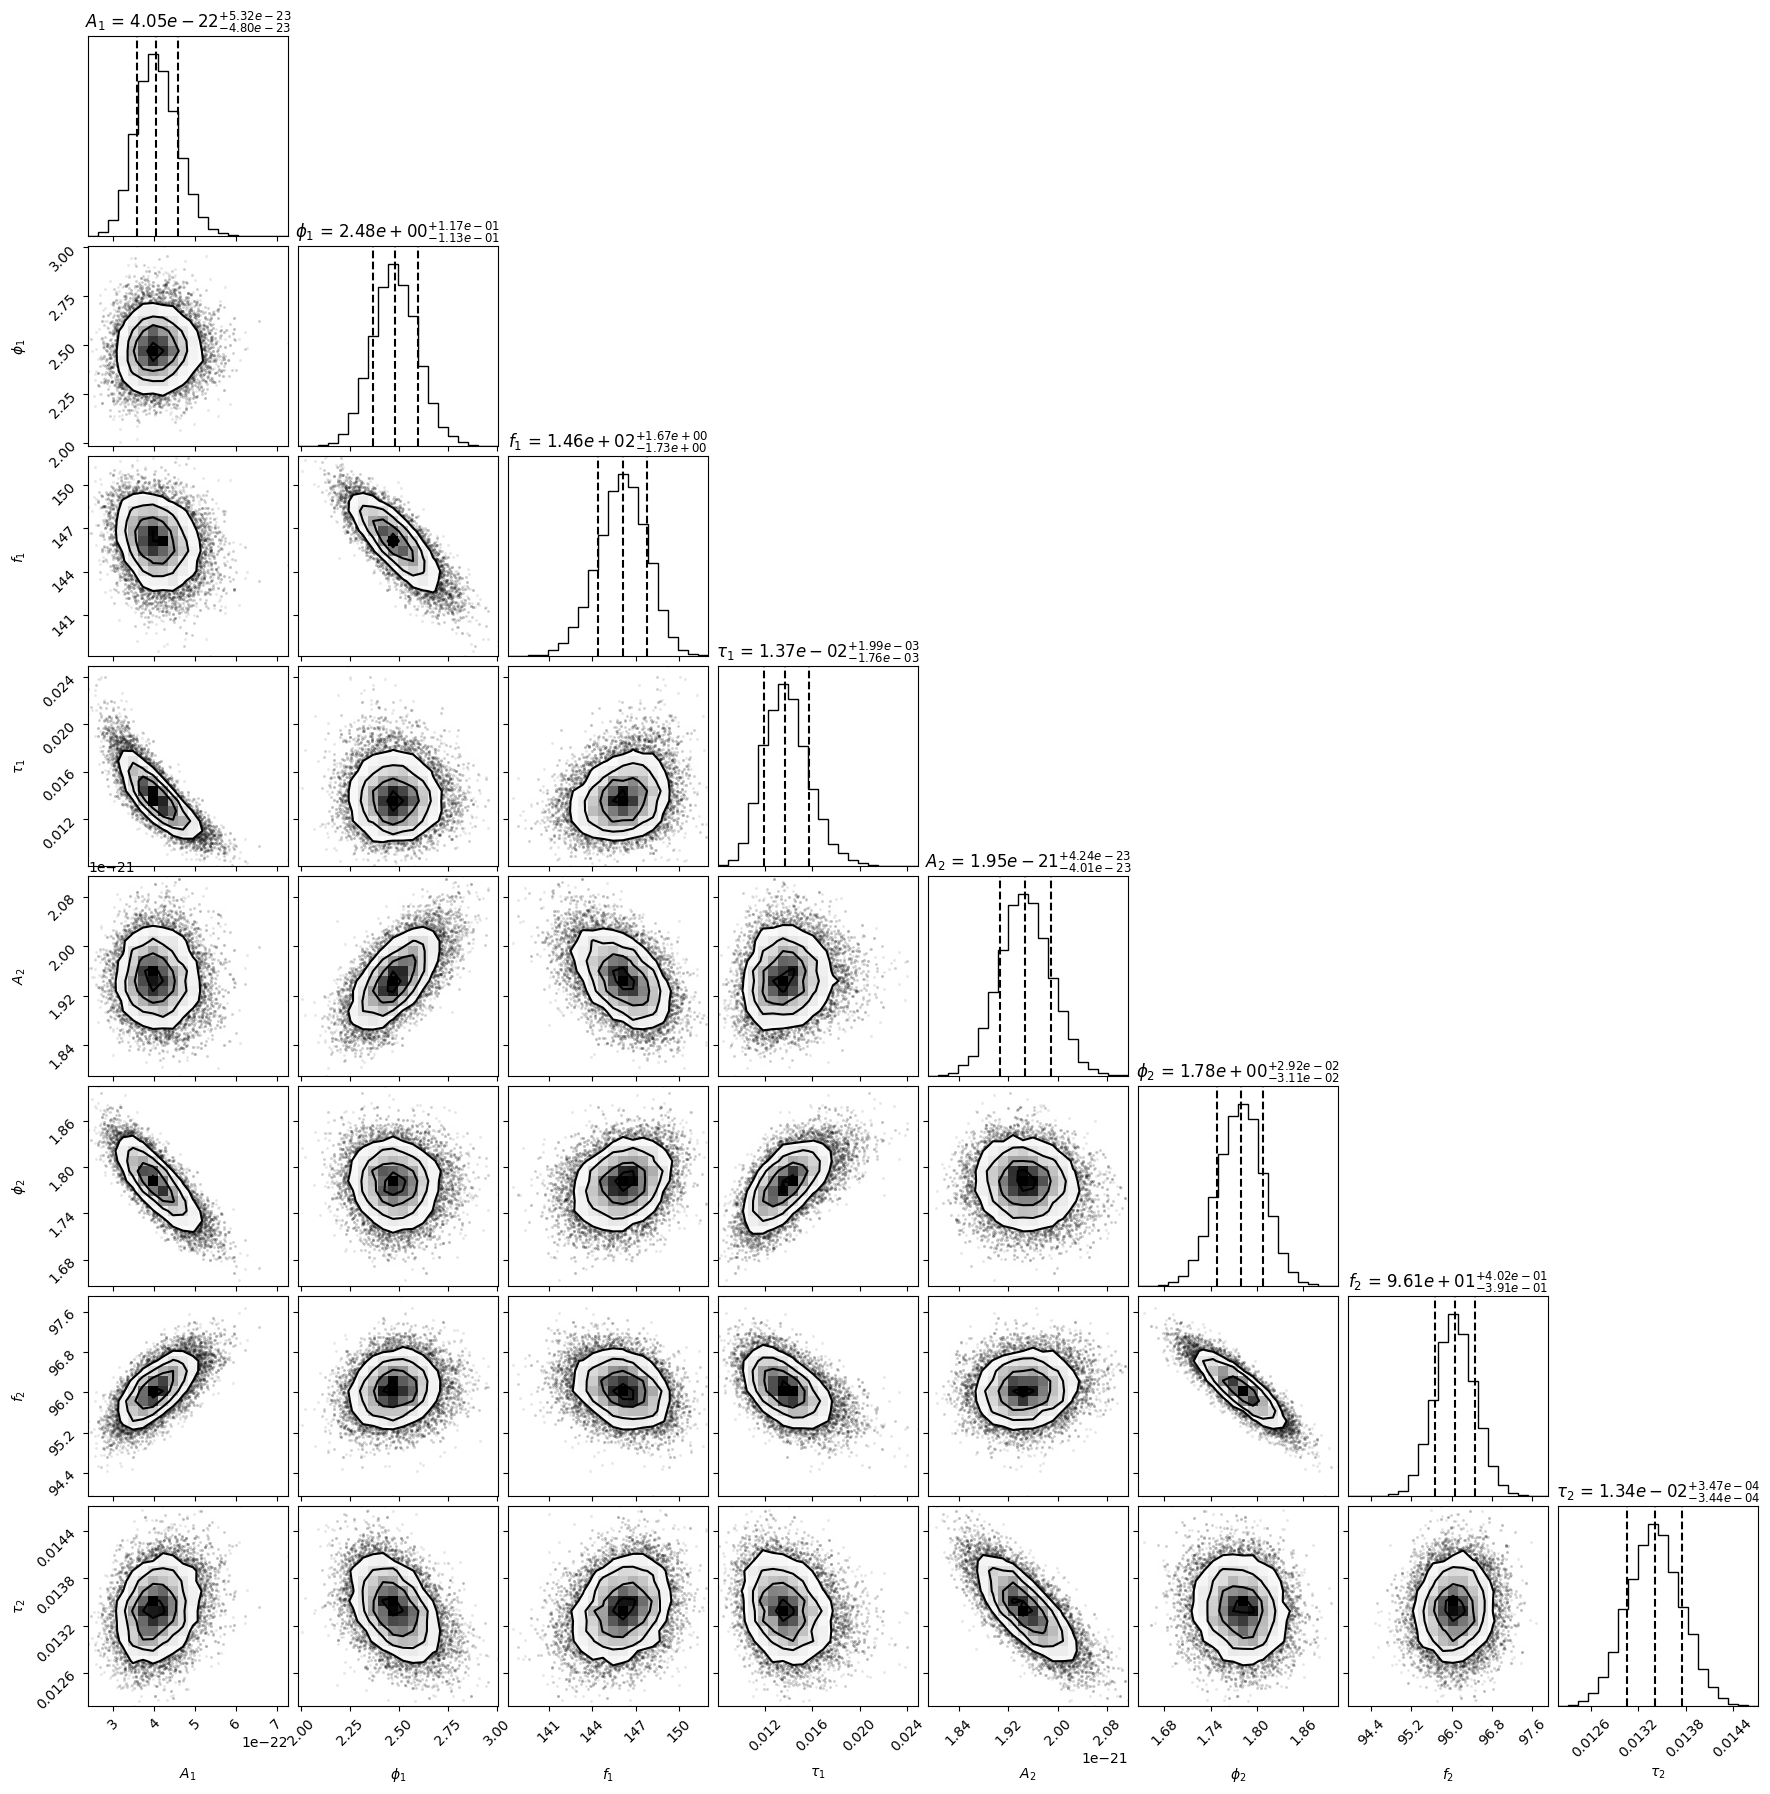

In [382]:
import corner

labels = [r"$A_1$", r"$\phi_1$", r"$f_1$", r"$\tau_1$",
          r"$A_2$", r"$\phi_2$", r"$f_2$", r"$\tau_2$"]

fig = corner.corner(
    samples,
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],  # 1-sigma credible intervals
    show_titles=True,
    title_fmt=".2e",
)

## Q5: Off-source PSD
- The problem is that the concatenation of the two off-source sections would lead to signal bleed.
- I will take a PSD for each and then average them.

In [383]:
from scipy.signal import welch

fs = 4096
f_1, PSD_1 = welch(d_off_1, fs=fs, nperseg=256, noverlap=128, window='hann')
f_2, PSD_2 = welch(d_off_2, fs=fs, nperseg=256, noverlap=128, window='hann')
# f = frequency array, PSD = power spectral density
PSD_mean = np.mean([PSD_1, PSD_2], axis=0)

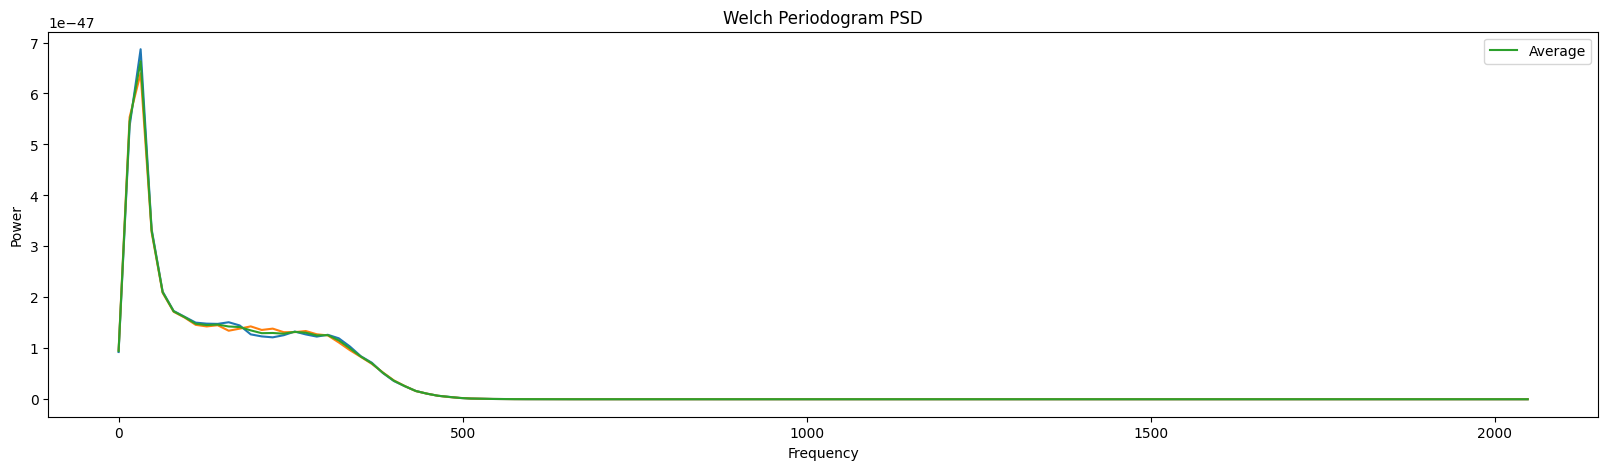

In [384]:
fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Frequency")
ax.set_ylabel("Power")
ax.plot(f_1, PSD_1)
ax.plot(f_2, PSD_2)
ax.plot(f_1, PSD_mean, label='Average')
ax.set_title("Welch Periodogram PSD")
ax.legend()



- Let's examine the instrument noise PSD.

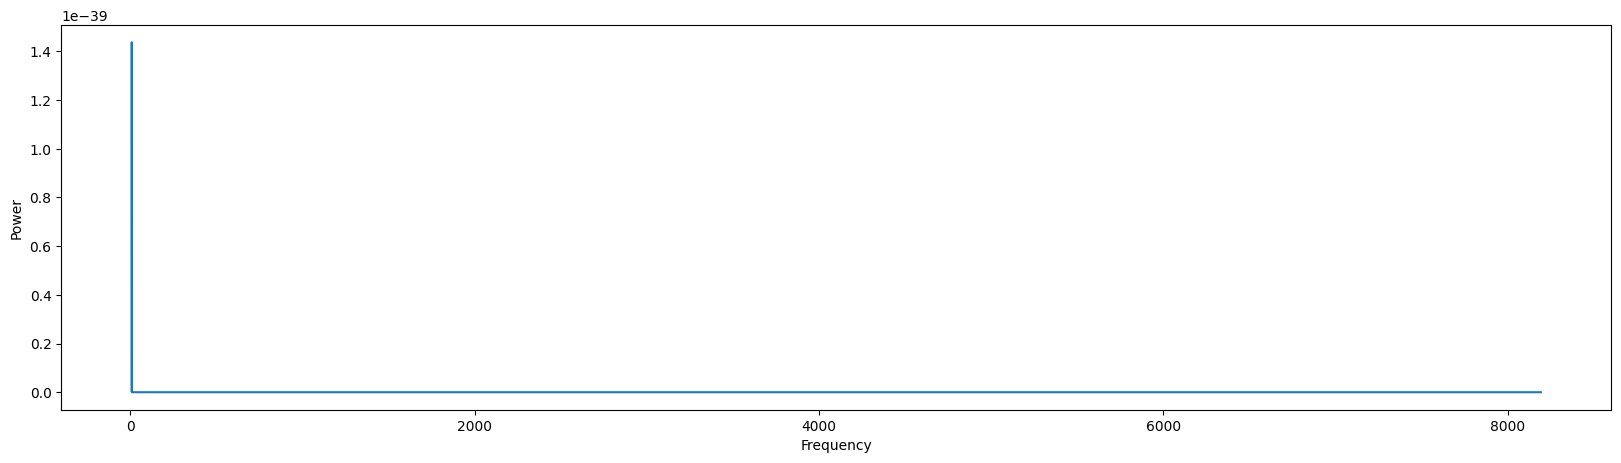

In [385]:
instrument_PSD = np.loadtxt('psd.dat', skiprows=1)
fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Frequency")
ax.set_ylabel("Power")
ax.plot(instrument_PSD[:,0], instrument_PSD[:,1])


- These should be estimates of the same thing.
- Rescale them to plot together.

(0.0, 1000.0)

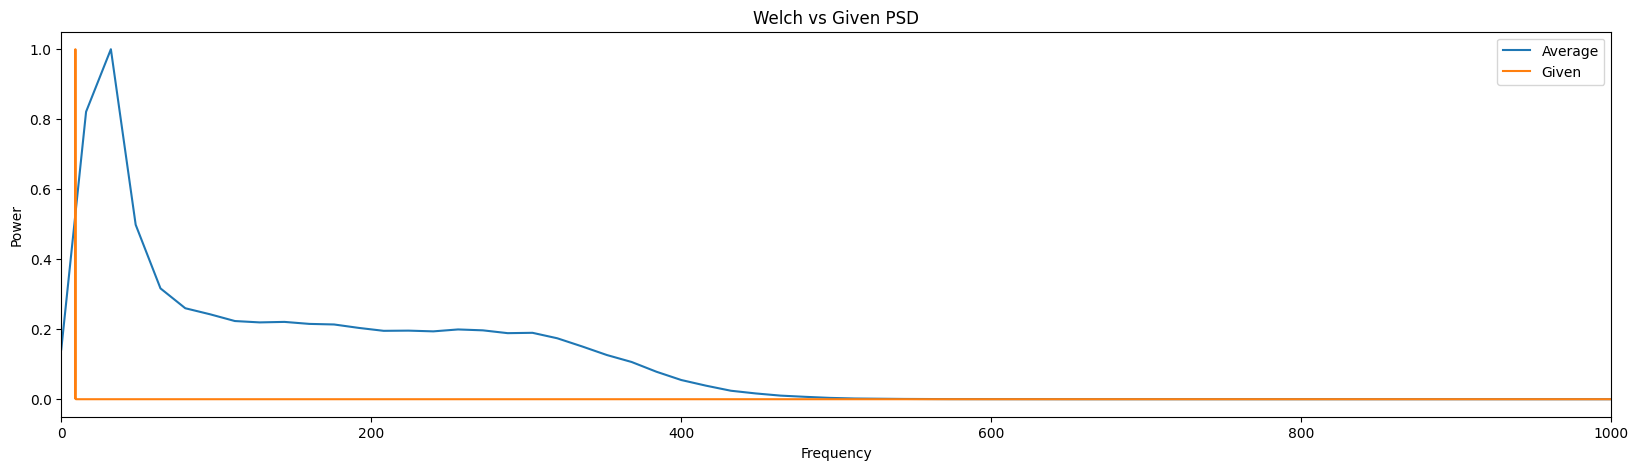

In [386]:
fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Frequency")
ax.set_ylabel("Power")

PSD_mean_rescaled = PSD_mean / max(PSD_mean)
PSD_instrument_rescaled = instrument_PSD[:,1] / max(instrument_PSD[:,1])

ax.plot(f_1, PSD_mean_rescaled, label='Average')
ax.plot(instrument_PSD[:,0], PSD_instrument_rescaled, label="Given")
ax.set_title("Welch vs Given PSD")
ax.legend()
ax.set_xlim(0,1000)


- The Welch periodogram is an empirical approximation so this doesn't seem too bad. Lower frequencies would require more data to be accurate so given limited data this seems reasonable.
- Sensible given the bandpass of 20-400 Hz.

## Q6: Calculate TDACF 
- If the white noise likelihood holds, the TDACF should be concentrates at 0 (subsequent points are uncorrelated).
- ACF and PSD are FFT pair.

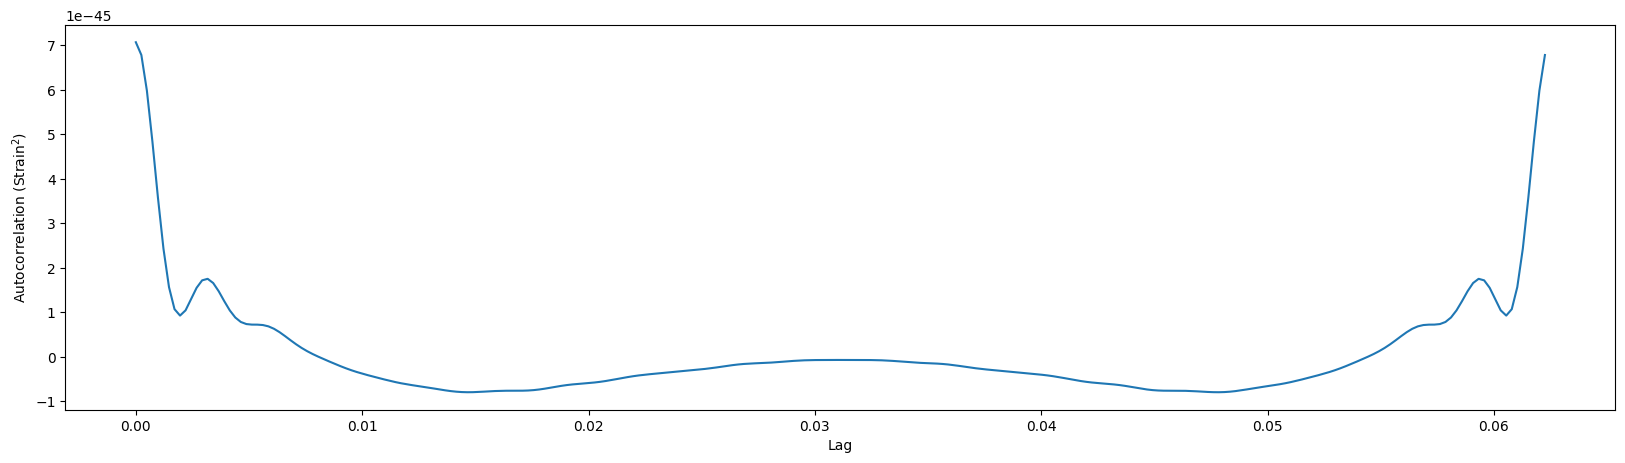

In [387]:
df = f_1[1] - f_1[0]  # sampling interval
N = 2 * (len(PSD_mean) - 1)

N_data = len(PSD_1) + len(PSD_2)# Len of the data
c95 = 1.96 / np.sqrt(N_data)

C = np.fft.irfft(PSD_mean) * df * N / 2   # units: strain²
tau = np.arange(N) * (1 / (N * df))  # lag axis in seconds


fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation (Strain$^2$)")
ax.plot(tau, C)

- This has two lobes because the IRFFT calculates positive and negative lags cyclically.
- Let's plot the first half.

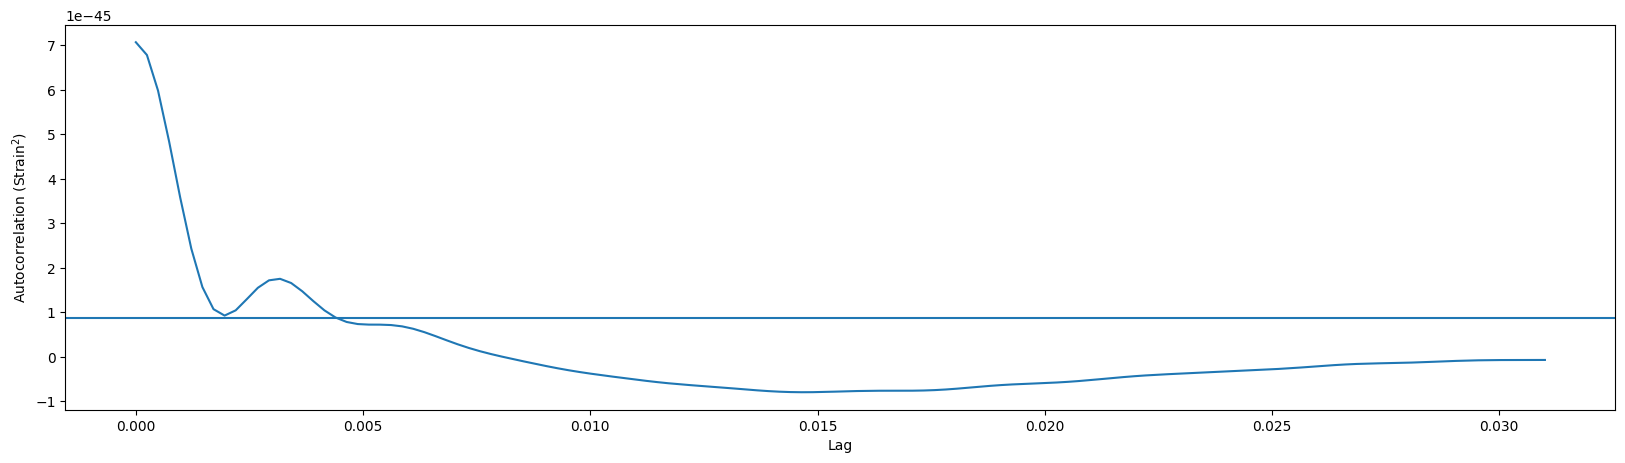

In [388]:
fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation (Strain$^2$)")

scaled_c95 =c95 * C[0]

N = len(tau)
ax.plot(tau[:N//2], C[:N//2])
ax.axhline(scaled_c95, label='95% noise threshold')

- This is more or less like white noise: our white noise kernel is a good choice.
- There is a peak that sits above the noise that is above the 95% confidence for noise so there is probably some other effect in the data.
- The tau = 0 lag is dominant though so I think the white noise kernel is still applicable.

In [389]:
tau[0], C[0]

(np.float64(0.0), np.float64(7.070439650219172e-45))

## Q7: Relating off_std to the ACF


In [390]:
rel = (C[0] - (off_std ** 2)) / (off_std ** 2)
print(f'Relative difference between variance and ACF at 0 lag is {rel:.2f}%')


Relative difference between variance and ACF at 0 lag is 0.02%


- This is pretty close.
- We would expace these values to be the same because of the autocorrelation definition $$R(\tau) = \left\langle x(t) \cdot x(t+\tau) \right\rangle_t$$.
- At tau = 0, we just expect the variance.

## Q8: GR and Kerr Metric Consistency Test
- Describe how.
- Perform it using this signal.

- Under the no-hair theorem, a black hole is fully characterised by $M$ and $\chi$.
- Each complex frequency $\omega_\alpha(M, \chi) = \frac{\hat\omega_\alpha(\chi)}{M}$
- $\hat\omega_\alpha(\chi)$ is fixed by GR.
- Every $\alpha$-mode is a function of the same two parameters.
- We have fit two modes from which we have extracted values of $f_\alpha = \frac{1}{2\pi} (\omega_\alpha + \frac{i}{\tau_\alpha})$ and $\tau_\alpha$.
- These values can be used to solve for $M$ and $\chi$.
- If GR is correct, these should line up (unless there is some deviation from the Kerr black hole ie exotic objects).

In [391]:
# 16th, 50th (median), 84th percentiles for each parameter
lo, med, hi = np.percentile(samples, [16, 50, 84], axis=0)

# for i, label in enumerate(labels):
#     lower_err = med[i] - lo[i]
#     upper_err = hi[i] - med[i]
#     print(f"{label}: {med[i]:.3e} +{upper_err:.3e} / -{lower_err:.3e}")

f1_med = med[2]
f1_lo, f1_hi = lo[2], hi[2]

f2_med = med[6]
f2_lo, f2_hi = lo[6], hi[6]

tau1_med = med[3]
tau1_lo, tau1_hi = lo[3], hi[3]

tau2_med = med[7]
tau2_lo, tau2_hi = lo[7], hi[7]

In [ ]:
print(f"f1_med = {f1_med:.1f} Hz")
print(f"f2_med = {f2_med:.1f} Hz")

# 220 mode has the lower frequency = f2

f1_med = 146.1 Hz
f2_med = 96.1 Hz


In [400]:
omega_330_ratio = omega_330.real / np.abs(omega_330.imag)

target_330 = 2 * np.pi * f1_med * tau1_med
lo_330 = 2 * np.pi * f1_lo * tau1_lo
hi_330 = 2 * np.pi * f1_hi * tau1_hi

# Find the argument of the target in the ratio using interpolation

chi_med_330 = np.interp(target_330, omega_330_ratio, chi_values)
chi_lo_330  = np.interp(lo_330, omega_330_ratio, chi_values)
chi_hi_330  = np.interp(hi_330, omega_330_ratio, chi_values)

chi_lo_330, chi_med_330, chi_hi_330

(np.float64(0.7443721649823877),
 np.float64(0.8234658750444326),
 np.float64(0.8762944329465976))

In [401]:
omega_220_ratio = omega_220.real / np.abs(omega_220.imag)

target_220 = 2 * np.pi * f2_med * tau2_med
lo_220 = 2 * np.pi * f2_lo * tau2_lo
hi_220 = 2 * np.pi * f2_hi * tau2_hi

# Find the argument of the target in the ratio using interpolation

chi_med_220 = np.interp(target_220, omega_220_ratio, chi_values)
chi_lo_220  = np.interp(lo_220, omega_220_ratio, chi_values)
chi_hi_220  = np.interp(hi_220, omega_220_ratio, chi_values)

chi_lo_220, chi_med_220, chi_hi_220

(np.float64(0.8063748754407011),
 np.float64(0.8201252746740259),
 np.float64(0.8326658003459603))

In [403]:
from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["Mode", "χ (16th)", "χ (median)", "χ (84th)"]
table.add_row(["(2,2,0)", f"{chi_lo_220:.4f}", f"{chi_med_220:.4f}", f"{chi_hi_220:.4f}"])
table.add_row(["(3,3,0)", f"{chi_lo_330:.4f}", f"{chi_med_330:.4f}", f"{chi_hi_330:.4f}"])
print(table)

+---------+----------+------------+----------+
|   Mode  | χ (16th) | χ (median) | χ (84th) |
+---------+----------+------------+----------+
| (2,2,0) |  0.8064  |   0.8201   |  0.8327  |
| (3,3,0) |  0.7444  |   0.8235   |  0.8763  |
+---------+----------+------------+----------+


- These are within uncertainty. Very good.
- Now to calculate M.

In [407]:
def convert_to_Msun(Mseconds):
    return Mseconds * 2.03e5

In [417]:
# Calculate Masses for 220
omega_hat_med_220, _, _ = mode_220(chi_med_220)
omega_hat_lo_220, _, _ = mode_220(chi_lo_220)
omega_hat_hi_220, _, _= mode_220(chi_hi_220)

M_med_220 = omega_hat_med_220.real / (2 * np.pi * f2_med)
M_lo_220 = omega_hat_lo_220.real / (2 * np.pi * f2_hi)
M_hi_220 = omega_hat_hi_220.real / (2 * np.pi * f2_lo)

M_med_220 = convert_to_Msun(M_med_220) 
M_lo_220 = convert_to_Msun(M_lo_220) 
M_hi_220 = convert_to_Msun(M_hi_220) 

In [416]:
# Calculate Masses for 330
omega_hat_med_330, _, _ = mode_330(chi_med_330)
omega_hat_lo_330, _, _ = mode_330(chi_lo_330)
omega_hat_hi_330, _, _ = mode_330(chi_hi_330)

M_med_330 = omega_hat_med_330.real / (2 * np.pi * f1_med)
M_lo_330 = omega_hat_lo_330.real / (2 * np.pi * f1_hi)
M_hi_330 = omega_hat_hi_330.real / (2 * np.pi * f1_lo)

M_med_330 = convert_to_Msun(M_med_330)
M_lo_330 = convert_to_Msun(M_lo_330)
M_hi_330 = convert_to_Msun(M_hi_330)

In [418]:
table = PrettyTable()
table.field_names = ["Mode", "M_low", "M_med", "M_high"]
table.add_row(["(2,2,0)", f"{M_lo_220:.2f}", f"{M_med_220:.2f}", f"{M_hi_220:.2f}"])
table.add_row(["(3,3,0)", f"{M_lo_330:.2f}", f"{M_med_330:.2f}", f"{M_hi_330:.2f}"])
print(table)

+---------+--------+--------+--------+
|   Mode  | M_low  | M_med  | M_high |
+---------+--------+--------+--------+
| (2,2,0) | 197.69 | 201.70 | 205.63 |
| (3,3,0) | 191.33 | 209.01 | 225.75 |
+---------+--------+--------+--------+
